# Tiki Vietnam E-commerce Market Analysis
## Goal
Analyze product data scraped from Tiki (one of Vietnam's largest e-commerce platforms) 
across six fashion and accessory categories — backpacks/suitcases, fashion accessories, 
men's bags, men's shoes, women's bags, and women's shoes — to uncover pricing patterns, 
brand and seller performance, and customer engagement (ratings, reviews, favourites) 
across the Vietnamese fashion e-commerce market.

**Issues to address:**
- Drop redundant index column (`Unnamed: 0`) carried over from the original export
- Check for duplicate `id` values across the 6 merged files (a product may appear in more than one category file)
- Standardize `category` column — many rows show a generic `"Root"` value instead of a meaningful category name
- Inspect `date_created` — stored as a numeric value, not a readable date; needs conversion/verification
- Handle missing values in `original_price`, `price`, `brand`, `current_seller`, and `description`
- Check consistency between `original_price` and `price` (e.g. price > original_price, or zero/negative values)
- Review `rating_average` and `review_count` — many products show `0` reviews with `0.0` rating, which may need to be treated as "no reviews yet" rather than a true zero rating
- Verify data types (e.g. `pay_later`, `has_video` should be boolean; `quantity_sold` should be numeric)
- Check for duplicate product names/listings beyond `id` (possible re-listed items)

## Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Merge Data
**Note:** Merged 6 category CSV files (backpacks/suitcases, fashion accessories, men's 
bags, men's shoes, women's bags, women's shoes) into a single DataFrame. Added a 
`source_category` column (later renamed to `category`) to reliably track which file 
each product came from, since the original `category` field turned out to be unreliable 
(see below). Result: 41,603 rows × 20 columns.

In [38]:
files = {
    'backpacks_suitcases': '../Data/Raw/vietnamese_tiki_products_backpacks_suitcases.csv',
    'fashion_accessories': '../Data/Raw/vietnamese_tiki_products_fashion_accessories.csv',
    'men_bags': '../Data/Raw/vietnamese_tiki_products_men_bags.csv',
    'men_shoes': '../Data/Raw/vietnamese_tiki_products_men_shoes.csv',
    'women_bags': '../Data/Raw/vietnamese_tiki_products_women_bags.csv',
    'women_shoes': '../Data/Raw/vietnamese_tiki_products_women_shoes.csv'
}
dfs = []
for label, file in files.items():
    df = pd.read_csv(file)
    df['source_category'] = label
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.shape

(41603, 20)

## Initial Data Overview
**Note:** Used `head()`, `tail()`, `info()`, `describe(include='all')`, and `isnull().sum()` 
to get a first look at the merged dataset before cleaning.

Key observations:
- 41,603 rows, 20 columns; most columns are fully populated
- `fulfillment_type` and `brand` have a small number of missing values (1 and 2 respectively)
- `price`/`original_price` show a min of 0, which is invalid for a real product listing
- `brand` has 824 unique values, but `"OEM"` alone accounts for the vast majority — most 
  products are unbranded/generic
- `date_created` is stored as an integer, not a readable date — needs further investigation

In [39]:
df.head()

,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold,source_category
0,0,179731375,Balo nữ da dầy thời trang unisex màu sắc tươi ...,Balo nữ da dầy thời trang unisex màu sắc tươ...,14250,14250,dropship,OEM,0,0.0,0,False,Thiên Ân Balo,488,10,0,False,Balo nữ,0,backpacks_suitcases
1,1,249221065,Ví da đựng thẻ ngân hàng (7 màu) - 9205,...,10260,10260,dropship,OEM,0,0.0,0,False,SHOP THỜI TRANG 2N,166,2,0,False,Root,0,backpacks_suitcases
2,2,102862196,Balo nam nữ thời trang họa tiết bò sữa kiểu m...,Balo họa tiết bò sữa thời trang cho nam...,19999,19999,dropship,OEM,0,0.0,0,False,Xưởng may balo Đà Nẵng,831,5,0,False,Root,0,backpacks_suitcases
3,3,115740385,Vải nhũ bóng simili chống thấm may túi ví balo...,_ Vải nhũ bóng siêu xinh và cực kì xịn ...,30000,30000,dropship,OEM,0,0.0,0,False,BB Outlet,775,4,0,False,Root,0,backpacks_suitcases
4,4,102862375,Combo balo vừa a4 và túi tote thời trang kiểu...,BALO THỜI TRANG - BALO ĐẸP – BALO HỌC S...,29000,29000,dropship,OEM,0,0.0,0,False,Xưởng may balo Đà Nẵng,831,5,0,False,Root,0,backpacks_suitcases


In [40]:
df.tail()

,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold,source_category
41598,5914,165961767,Xịt khử mùi giày dép chống hôi chân,- Đánh bay nỗi lo lắng phiền muộn về mùi hôi c...,55000,55000,dropship,\tOEM,0,0.0,0,False,A Bảo Store 88,559,6,0,False,Vệ sinh giày,0,women_shoes
41599,5915,253164871,Bộ kit CAO CẤP vệ sinh giày Sneaker Cleaning 1...,Bộ kit CAO CẤP vệ sinh giày Sneaker Cle...,129000,129000,dropship,OEM,0,0.0,0,True,Hàng Gia Dụng Q9,132,9,0,False,Root,0,women_shoes
41600,5916,202330632,Xi đánh giày Kangaroo Hàn Quốc-KGR1,Làm sạch và bảo vệ bề mặt da Xi đánh ...,18000,18000,dropship,OEM,0,0.0,0,False,happyjew,324,6,0,False,Root,0,women_shoes
41601,5917,252614724,"Gói 30 giấy lau giày, đồ đa Sneaker","Gói 30 khăn lau giày thể thao, giày da,...",39900,39900,dropship,OEM,0,0.0,0,False,Kho hàng Hạnh Phạm SG,143,9,1061,False,Root,0,women_shoes
41602,5918,253296293,"Chai Tẩy Trắng Giày Dép Vết Ố Vàng, Vệ Sinh Tú...",Giày Snoker thể thao là xu hướng chủ đạ...,91757,91757,dropship,OEM,0,0.0,0,False,Kho hàng Thảo Trang,128,9,0,False,Root,0,women_shoes


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41603 entries, 0 to 41602
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        41603 non-null  int64  
 1   id                41603 non-null  int64  
 2   name              41603 non-null  str    
 3   description       41603 non-null  str    
 4   original_price    41603 non-null  int64  
 5   price             41603 non-null  int64  
 6   fulfillment_type  41602 non-null  str    
 7   brand             41601 non-null  str    
 8   review_count      41603 non-null  int64  
 9   rating_average    41603 non-null  float64
 10  favourite_count   41603 non-null  int64  
 11  pay_later         41603 non-null  bool   
 12  current_seller    41603 non-null  str    
 13  date_created      41603 non-null  int64  
 14  number_of_images  41603 non-null  int64  
 15  vnd_cashback      41603 non-null  int64  
 16  has_video         41603 non-null  bool   
 17  cate

In [42]:
df.describe(include='all')

,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold,source_category
count,41603.000000,4.160300e+04,41603,41603,4.160300e+04,4.160300e+04,41602,41601,41603.000000,41603.000000,41603.0,41603,41603,41603.000000,41603.000000,41603.000000,41603,41603,41603.000000,41603
unique,NaN,NaN,38281,30849,NaN,NaN,4,824,NaN,NaN,NaN,2,3807,NaN,NaN,NaN,2,155,NaN,6
top,NaN,NaN,Ví Nữ Cầm Tay Da Cao Cấp - Ví Cầm Tay - Ví Đựn...,...,NaN,NaN,dropship,OEM,NaN,NaN,NaN,False,Shalla,NaN,NaN,NaN,False,Root,NaN,fashion_accessories
freq,NaN,NaN,16,655,NaN,NaN,40689,30692,NaN,NaN,NaN,23104,542,NaN,NaN,NaN,37330,16595,NaN,16019
mean,4686.910151,1.465338e+08,NaN,NaN,3.049050e+05,2.722998e+05,NaN,NaN,3.111266,1.381823,0.0,NaN,NaN,711.069394,5.969618,1431.372113,NaN,NaN,17.769608,NaN
std,4078.647296,6.363728e+07,NaN,NaN,8.516887e+05,7.628272e+05,NaN,NaN,18.225705,2.105392,0.0,NaN,NaN,6273.494694,3.455436,6388.220608,NaN,NaN,168.325526,NaN
min,0.000000,1.599010e+05,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.000000,0.000000,0.0,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,0.000000,NaN
25%,1733.000000,1.021183e+08,NaN,NaN,4.000000e+04,3.900000e+04,NaN,NaN,0.000000,0.000000,0.0,NaN,NaN,397.000000,4.000000,0.000000,NaN,NaN,0.000000,NaN
50%,3466.000000,1.523704e+08,NaN,NaN,9.000000e+04,8.500000e+04,NaN,NaN,0.000000,0.000000,0.0,NaN,NaN,616.000000,6.000000,0.000000,NaN,NaN,0.000000,NaN
75%,5768.000000,1.935446e+08,NaN,NaN,2.400000e+05,2.100000e+05,NaN,NaN,1.000000,4.000000,0.0,NaN,NaN,831.000000,8.000000,0.000000,NaN,NaN,5.000000,NaN


In [43]:
df.isnull().sum()

Unnamed: 0          0
id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    1
brand               2
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
source_category     0
dtype: int64

## Handle Missing Values
**Note:** Found 3 missing values total: 1 in `fulfillment_type`, 2 in `brand`. Both 
missing `brand` rows share the same seller and category. Since the dataset already uses 
`"OEM"` to represent unbranded products, missing values are filled with `"Unknown"` 
instead of dropping the rows — this preserves the price, rating, and category information 
for these products, which is more valuable than losing 3 rows over 1 missing field.

In [44]:
df[df['fulfillment_type'].isnull() | df['brand'].isnull()]

,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold,source_category
7569,2208,116639473,Gấp bầu đính đá,...,25000,25000,dropship,NaN,0,0.0,0,False,Kana BT,768,1,0,False,Cài tóc,0,fashion_accessories
14328,8967,116638584,Combo 8 ống cuốn mues,Chuyen si le phu kien tóc / trang suc ...,20000,20000,dropship,NaN,0,0.0,0,False,Kana BT,769,3,0,False,Dụng cụ uốn tóc và tạo kiểu,0,fashion_accessories
29935,4321,799279,Giày Tây Nam Cột Dây VNL VNL1A2TK0TD - Nâu,"Giày Tây Nam Cột Dây VNL VNL1A2TK0TD màu nâu, ...",549000,549000,NaN,VNL,0,0.0,0,True,Da Giày Việt Nam,2140,5,0,False,Thời Trang,0,men_shoes


In [45]:
df['brand'] = df['brand'].fillna('Unknown')
df['fulfillment_type'] = df['fulfillment_type'].fillna('Unknown')

In [46]:
df = df.drop(columns=['Unnamed: 0'])

**Note:** Dropped `Unnamed: 0` — this was a leftover row index from each original CSV 
export, not a meaningful column, and became redundant/duplicated once the 6 files were merged.

In [47]:
df.duplicated(subset=['id']).sum()

np.int64(27)

In [48]:
(df['price'] == 0).sum(), (df['original_price'] == 0).sum()

(np.int64(1), np.int64(1))

In [49]:
df['category'].value_counts()


category
Root                          16595
Thời Trang                     4230
Ví nam đứng                     639
Ví nam ngang                    584
Túi xách công sở nam            471
                              ...  
Áo thun nam ngắn tay có cổ        1
Giày sandals nam                  1
Kính Hiển Vi                      1
Phụ kiện giày nam                 1
Cây cảnh                          1
Name: count, Length: 155, dtype: int64

In [50]:
df = df.drop(columns=['category'])

In [51]:
df = df.rename(columns={'source_category': 'category'})

**Note on `category`:** The original `category` field returned `"Root"` for 16,595 of 
41,603 rows (~40%) — a generic placeholder Tiki uses when a product's full category path 
wasn't captured during crawling. Since this makes the field unreliable, it was dropped in 
favor of `source_category` (renamed to `category`), which was derived directly from which 
file each product came from.

## Handle Invalid Prices and Duplicate Products
**Note:** A small number of rows (1 row each) have `price` or `original_price` equal to 0. 
This is likely a data entry/crawling error rather than a genuine free promotion, since Tiki 
does not list products at 0 VND. These rows are dropped to avoid skewing price-based analysis.

Additionally, 27 duplicate `id` values were found across the merged files — likely products 
that appear in more than one category listing. These duplicates are removed, keeping the 
first occurrence.

In [52]:
df = df[(df['price'] != 0 ) & (df['original_price'] != 0 )]

In [53]:
df = df.drop_duplicates(subset=['id'], keep='first')

## Fix Data Types
**Note:** Verified `pay_later` and `has_video` contained only `True`/`False` values and 
converted both from string-like objects to proper `bool` dtype for accurate filtering and 
aggregation later.

In [54]:
df['pay_later'].unique(), df['has_video'].unique()

(array([False,  True]), array([False,  True]))

In [55]:
df['pay_later'] = df['pay_later'].astype(bool)
df['has_video'] = df['has_video'].astype(bool)

In [56]:
df['pay_later'].dtype, df['has_video'].dtype

(dtype('bool'), dtype('bool'))

## Investigate `date_created` Outliers
The dataset documentation does not clearly define `date_created`. Based on its 
distribution (25th–75th percentile: 396–831), it likely represents the number of days 
since the product was listed. However, 3 rows shared an identical, implausible value of 
738,076 — a clear crawling/placeholder error rather than real data (all 3 belonged to the 
same brand, Mikkor, in `backpacks_suitcases`). These rows were dropped. After removing 
them, the distribution is far more reasonable (mean ≈ 658, max ≈ 2,889 days).

In [57]:
df['date_created'].head()

0    488
1    166
2    831
3    775
4    831
Name: date_created, dtype: int64

In [58]:
df['date_created'].describe()

count     41575.000000
mean        711.186410
std        6275.605097
min           0.000000
25%         396.500000
50%         616.000000
75%         831.000000
max      738076.000000
Name: date_created, dtype: float64

In [59]:
df[df['date_created'] > 3000][['id', 'name', 'date_created', 'category']]

,id,name,date_created,category
1747,497990,Balo Mikkor Pretty Backpack New PB009 - Màu Kaki,738076,backpacks_suitcases
2587,790799,Balo Laptop Mikkor The Edwin TEB001 - Đen (15....,738076,backpacks_suitcases
3478,476610,"Cặp Đeo Laptop Mikkor Glamour Mac GM 13"" 005 -...",738076,backpacks_suitcases


In [60]:
df = df[df['date_created'] <= 3000]


In [61]:
df['date_created'].describe()

count    41572.000000
mean       657.975248
std        382.422967
min          0.000000
25%        396.000000
50%        616.000000
75%        831.000000
max       2889.000000
Name: date_created, dtype: float64

## Clean Text Columns (Whitespace/Tab Issues)
Found that `brand` contains inconsistent values due to leading/trailing whitespace or tab 
characters (e.g. `"\tOEM"` vs `"OEM"` being treated as different brands). Stripping whitespace 
from all text columns to ensure accurate grouping and counting.

In [62]:
text_cols = df.select_dtypes(include=['object', 'str']).columns
df[text_cols] = df[text_cols].apply(lambda x: x.str.strip())

df['brand'].value_counts().head()

brand
OEM            31131
Song An Eco      509
Huy Hoàng        352
Hạnh Dương       227
ANANSHOP688      197
Name: count, dtype: int64

## Fix Corrupted Brand Value

Found one row (`id = 172347067`) where `brand` contains a stray `<` character 
(`"Anse<"`), likely leftover from an incomplete HTML tag during crawling. Since only 
this single brand value is affected, the text after `<` is removed to recover the 
correct brand name (`"Anse"`).

In [63]:
df[df['brand'].str.contains('<|>', na=False)]['brand'].unique()

<StringArray>
['Anse<']
Length: 1, dtype: str

In [64]:
df['brand'] = df['brand'].str.split('<').str[0].str.strip()

In [65]:
df[df['id'] == 172347067]['brand']

35358    Anse
Name: brand, dtype: object

## Export Cleaned CSV File
**Note:** Exported the fully cleaned dataset (41,572 rows × 18 columns) to 
`Data/Processed/tiki_products_cleaned.csv` for use in SQL analysis and the Power BI dashboard.

In [66]:
df.to_csv('../Data/Processed/tiki_products_cleaned.csv', index=False)

## Exploratory Data Analysis (EDA)
Before moving to SQL queries and Power BI, this section explores the cleaned dataset to 
understand price distribution, category performance, brand competition, and customer 
engagement patterns (ratings, reviews, sales).

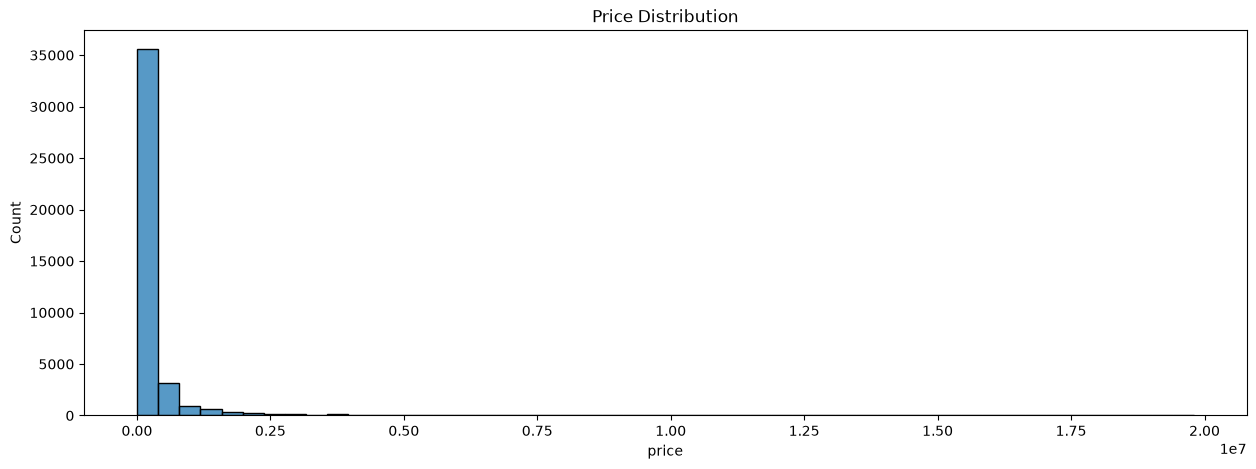

In [67]:
plt.figure(figsize=(15,5))
sns.histplot(df['price'], bins=50)
plt.title('Price Distribution')
plt.show()

**Insight:** Price is heavily right-skewed — the vast majority of products are priced 
under ~500,000 VND, with a long tail of premium items reaching up to ~19.8M VND. This is 
typical of a mixed fashion marketplace with both mass-market accessories and premium bags/luggage.

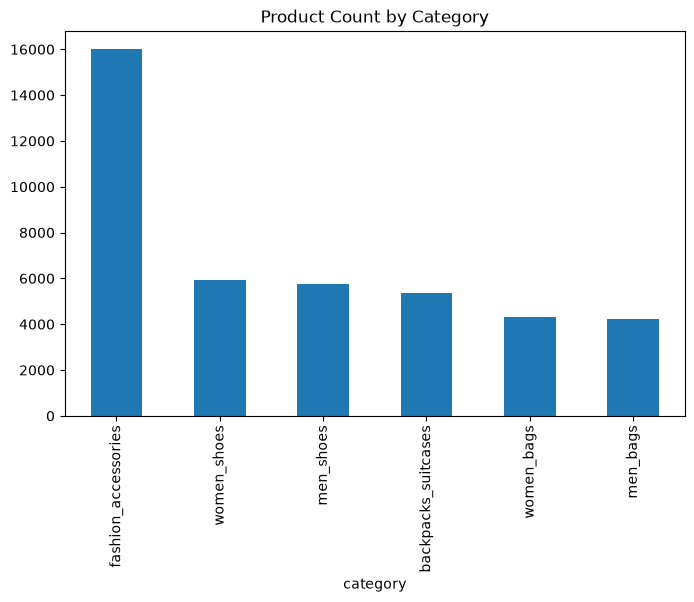

In [68]:
df['category'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title('Product Count by Category')
plt.show()

**Insight:** `fashion_accessories` dominates the dataset with ~16,000 listings — more than 
double any other category — while the remaining five categories (women's/men's shoes, 
backpacks/suitcases, women's/men's bags) are fairly evenly distributed between ~4,200 and 
~6,000 listings each.

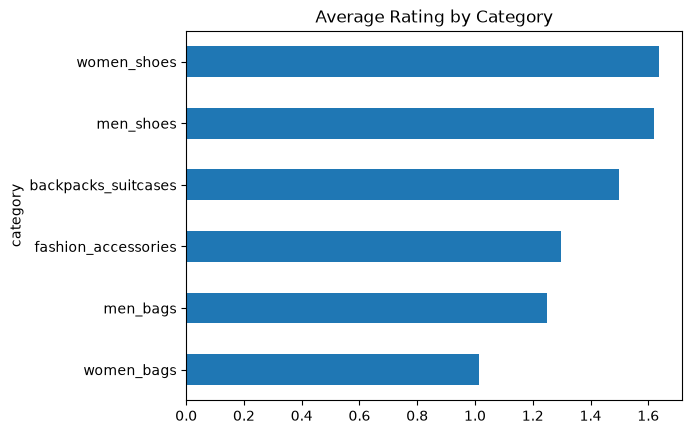

In [69]:
df.groupby('category')['rating_average'].mean().sort_values().plot(kind='barh')
plt.title('Average Rating by Category')
plt.show()

**Insight:** Average ratings across all categories are notably low (roughly 1.0–1.6 out of 
a 5-point scale), with `women_shoes` and `men_shoes` rated highest and `women_bags` lowest. 
This is likely driven by the large share of products with zero reviews (`rating_average = 0` 
by default), which pulls the category averages down — a true "average rating among rated 
products only" would need to filter out `review_count = 0` first.

In [70]:
df['brand'].value_counts().head(10)

brand
OEM                              31131
Song An Eco                        509
Huy Hoàng                          352
Hạnh Dương                         227
ANANSHOP688                        197
GOMTAT                             192
BIGGBEN                            189
Converse                           186
Bee Gee                            174
Trương Gia Túi Vải Túi Canvas      170
Name: count, dtype: int64

**Insight:** `"OEM"` (generic/unbranded) accounts for ~75% of all products (31,131 of 
41,572), confirming that Tiki's fashion accessory market is dominated by unbranded or 
white-label goods rather than name brands. Beyond OEM, no single named brand holds more 
than ~1.2% of listings — the branded segment is highly fragmented.

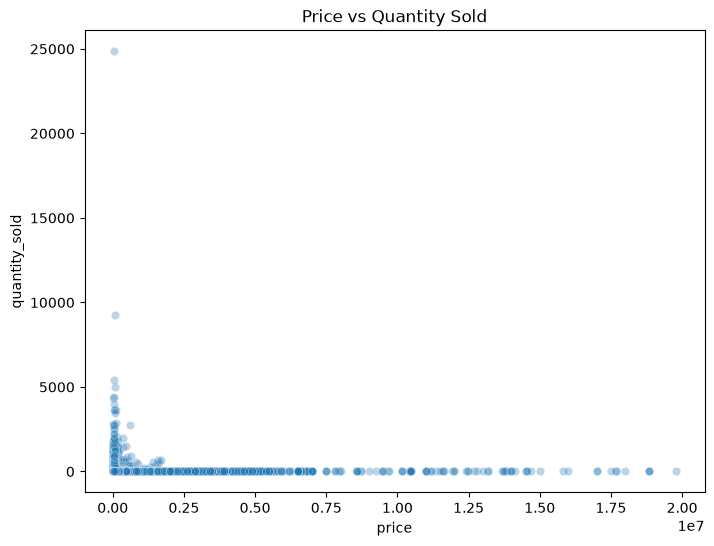

In [71]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='price', y='quantity_sold', alpha=0.3)
plt.title('Price vs Quantity Sold')
plt.show()

**Insight:** No clear linear relationship between price and quantity sold — most sales 
volume, including the highest-selling outliers (up to ~25,000 units), cluster at the 
lower end of the price range, while expensive products (>5M VND) consistently sell in 
very small quantities. This suggests price alone is a weak predictor of sales volume, 
consistent with the near-zero correlation found later (-0.02).

### Note on `favourite_count`

All values in `favourite_count` are 0, meaning this column carries no variance and 
therefore no analytical value. It is excluded from the correlation matrix and further analysis.

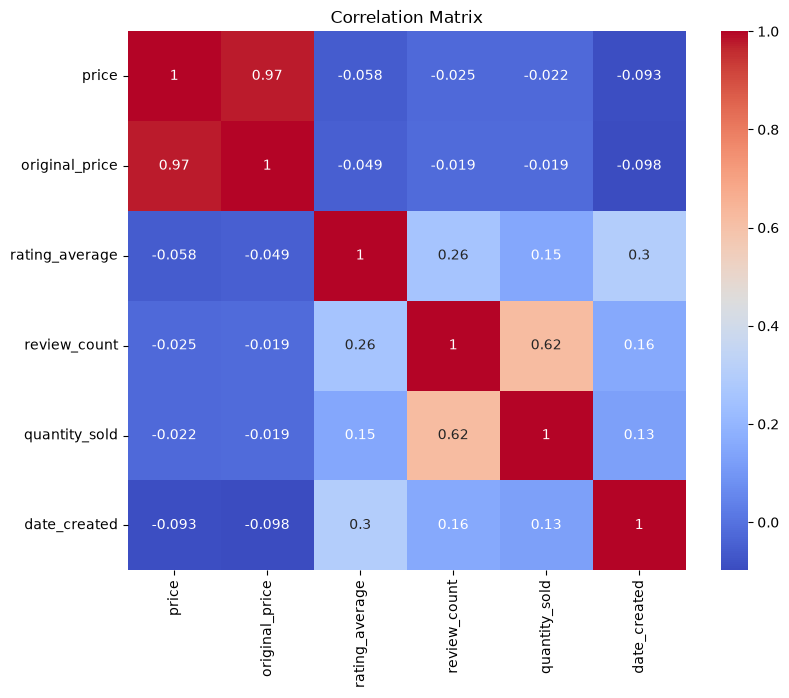

In [72]:
numeric_cols = ['price', 'original_price', 'rating_average', 'review_count', 
                 'quantity_sold', 'date_created']
plt.figure(figsize=(9,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Analysis:**

- `price` and `original_price` are almost perfectly correlated (0.97), which is expected 
  since discounted price is directly derived from original price — this near-duplication 
  means only one of the two should be used as a predictor in further modeling to avoid 
  multicollinearity.
- `review_count` and `quantity_sold` show the strongest relationship in the dataset (0.62), 
  suggesting that products with more reviews tend to sell more — likely reflecting either 
  higher trust from social proof, or simply that more units sold naturally generates more reviews.
- `rating_average` has weak positive correlations with `review_count` (0.26), `quantity_sold` 
  (0.15), and `date_created` (0.3) — better-rated products get modestly more engagement, but 
  rating alone is not a strong driver of sales volume.
- Price (`price`, `original_price`) shows almost no correlation with `quantity_sold` (-0.02) 
  or `rating_average` (-0.05 to -0.06), indicating that price is not a major factor in either 
  how much a product sells or how it's rated — cheaper products don't necessarily sell more, 
  and pricier products aren't rated worse.
- `date_created` has a mild positive correlation with `rating_average` (0.3) and `review_count` 
  (0.16), which makes sense: older listings (higher `date_created`, i.e. longer time on the 
  platform) have had more time to accumulate reviews and ratings.

### Key Findings

- **Market structure:** The dataset spans 41,572 cleaned product listings across 6 
  fashion/accessory categories on Tiki, with `fashion_accessories` making up nearly 40% 
  of all listings — the dominant category by volume.
- **Unbranded market:** ~75% of products are generic/unbranded (`"OEM"`), indicating price 
  and platform visibility likely matter more than brand recognition for most sellers on Tiki.
- **Price is not a strong driver of sales:** Correlation between `price` and `quantity_sold` 
  is negligible (-0.02), and the scatter plot shows top-selling products are concentrated at 
  lower price points — pricing strategy alone won't explain sales performance.
- **Reviews matter more than ratings:** `review_count` is the strongest numeric predictor of 
  `quantity_sold` (0.62), while `rating_average` has only a weak relationship (0.15) — social 
  proof volume (number of reviews) appears more influential on purchase decisions than the 
  average rating score itself.
- **Data quality issues resolved:** cleaned up crawling errors including a mislabeled 
  `category` field (~40% generic "Root" values), whitespace/tab corruption in `brand` 
  (`"\tOEM"`), a corrupted brand value (`"Anse<"`), and implausible `date_created` outliers — 
  all fixed with minimal data loss (fewer than 35 rows dropped in total out of 41,603).


## Connect to PostgreSQL and Load Data
Push the cleaned dataset into a local PostgreSQL database (`tiki_ecommerce`) using 
SQLAlchemy, so it can be queried with SQL and connected to Power BI.

In [73]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

username = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
database = os.getenv('DB_NAME')

engine = create_engine(f'postgresql://{username}:{password}@{host}:{port}/{database}')

df.to_sql('tiki_products', engine, if_exists='replace', index=False)

572